# Estudo Prático — Classificação de Risco de Crédito com Gaussian Naive Bayes

**Objetivo do estudo:** Aplicar o algoritmo **Gaussian Naive Bayes** em um problema de classificação utilizando um conjunto de dados de risco de crédito, explorando as principais etapas do pré-processamento, treinamento e avaliação do modelo.

**Dataset:** Credit Risk Dataset

**Fonte:** https://www.kaggle.com/laotse/credit-risk-dataset

---

## Sobre este estudo

Este notebook foi desenvolvido com fins de aprendizado em Machine Learning. O objetivo é compreender, na prática, o funcionamento do algoritmo **Gaussian Naive Bayes**, desde a exploração e preparação dos dados até o treinamento do modelo e a análise dos resultados obtidos.

---

## Resumo do estudo

* Foram identificados **3 valores negativos** no atributo **`age`**, considerados inconsistentes.
* Após o tratamento dessas inconsistências, permaneceram **3 valores ausentes** na variável **`age`**, que foram preenchidos utilizando a **média das idades**.
* As variáveis preditoras utilizadas foram **`income`**, **`age`** e **`loan`**, enquanto a variável alvo (classe) foi **`default`**.
* Como as variáveis preditoras apresentavam escalas muito diferentes entre si, foi aplicada a **padronização (StandardScaler)** para colocá-las em uma mesma escala.
* A base de dados foi dividida em **75% para treinamento** e **25% para teste**.
* O modelo **Gaussian Naive Bayes** obteve uma **acurácia de 93,8%** no conjunto de teste.

---

## Etapas do estudo

* Importação das bibliotecas
* Exploração inicial dos dados
* Visualização dos dados
* Tratamento dos valores inconsistentes
* Divisão entre variáveis preditoras e variável alvo
* Divisão da base em treinamento e teste
* Salvamento das variáveis
* Aplicação do algoritmo Gaussian Naive Bayes
* Avaliação do modelo

---

**Observação:** O algoritmo Gaussian Naive Bayes não exige obrigatoriamente o escalonamento das variáveis, pois realiza os cálculos de probabilidade para cada atributo individualmente. Neste estudo, a padronização com o `StandardScaler` foi aplicada para fins didáticos e para manter um fluxo de pré-processamento consistente com outros algoritmos de Machine Learning.


#### Importação das Bibliotecas

In [40]:
# Importando as bibliotecas
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pickle
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, ConfusionMatrixDisplay

#### Exploração Inicial dos Dados

In [41]:
# Carregando o dataset 
df = pd.read_csv('credit_data.csv')

In [42]:
# Visualização inicial
df

,clientid,income,age,loan,default
0,1,66155.925095,59.017015,8106.532131,0
1,2,34415.153966,48.117153,6564.745018,0
2,3,57317.170063,63.108049,8020.953296,0
3,4,42709.534201,45.751972,6103.642260,0
4,5,66952.688845,18.584336,8770.099235,1
...,...,...,...,...,...
1995,1996,59221.044874,48.518179,1926.729397,0
1996,1997,69516.127573,23.162104,3503.176156,0
1997,1998,44311.449262,28.017167,5522.786693,1
1998,1999,43756.056605,63.971796,1622.722598,0


In [43]:
# Primeiras linhas
df.head()

,clientid,income,age,loan,default
0,1,66155.925095,59.017015,8106.532131,0
1,2,34415.153966,48.117153,6564.745018,0
2,3,57317.170063,63.108049,8020.953296,0
3,4,42709.534201,45.751972,6103.642260,0
4,5,66952.688845,18.584336,8770.099235,1


In [44]:
# últimas linhas
df.tail()

,clientid,income,age,loan,default
1995,1996,59221.044874,48.518179,1926.729397,0
1996,1997,69516.127573,23.162104,3503.176156,0
1997,1998,44311.449262,28.017167,5522.786693,1
1998,1999,43756.056605,63.971796,1622.722598,0
1999,2000,69436.579552,56.152617,7378.833599,0


In [45]:
# Estatísticas básicas
df.describe()

,clientid,income,age,loan,default
count,2000.000000,2000.000000,1997.000000,2000.000000,2000.000000
mean,1000.500000,45331.600018,40.807559,4444.369695,0.141500
std,577.494589,14326.327119,13.624469,3045.410024,0.348624
min,1.000000,20014.489470,-52.423280,1.377630,0.000000
25%,500.750000,32796.459717,28.990415,1939.708847,0.000000
50%,1000.500000,45789.117313,41.317159,3974.719419,0.000000
75%,1500.250000,57791.281668,52.587040,6432.410625,0.000000
max,2000.000000,69995.685578,63.971796,13766.051239,1.000000


Pode-se verificar valores negativos no atributo age, que serão tratados utilizando a média das idades na etapa tratamento de valores inconsistentes. 

In [46]:
# Verificando se existem valores ausentes
df.isnull().sum()

clientid    0
income      0
age         3
loan        0
default     0
dtype: int64

Observou-se 3 valores ausentes no atributo age, que serão preenchidos com a média das idades na etapa tratamento de valores ausentes.

In [47]:
# Verificando o cliente com a maior renda
df[df['income'] >= 69995.685578]

,clientid,income,age,loan,default
422,423,69995.685578,52.719673,2084.370861,0


In [48]:
# Verificando o cliente com a menor dívida
df[df['loan'] <= 1.377630]

,clientid,income,age,loan,default
865,866,28072.604355,54.142548,1.37763,0


#### Visualização dos Dados

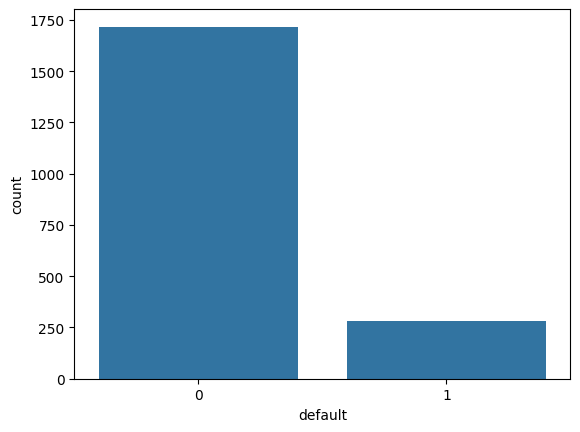

In [49]:
# Histograma da distribuição da variável alvo default
sns.countplot(x = df['default']);

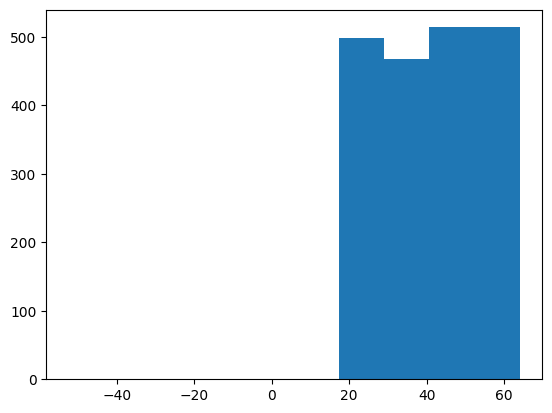

In [50]:
# Histograma da distribuição da variável age
plt.hist(x = df['age']);

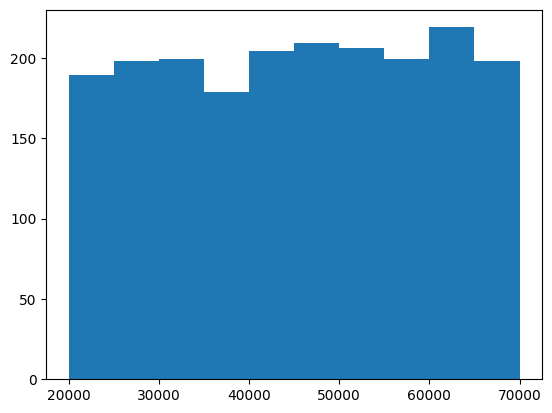

In [51]:
# Histograma da distribuição da variável income
plt.hist(x = df['income']);


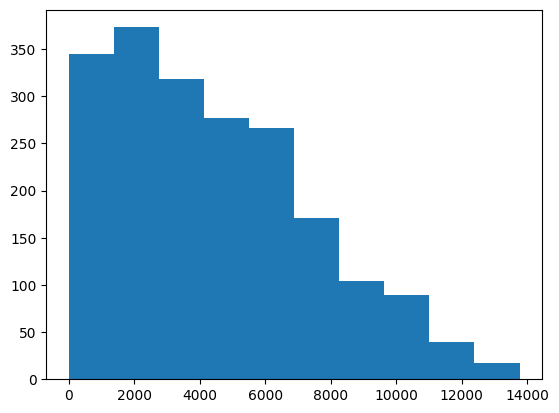

In [52]:
# Histograma da distribuição da variável loan
plt.hist(x = df['loan']);

#### Tratamento de Valores Inconsistentes 

In [53]:
# Localizando os valores negativos no atributo age 
df.loc[df['age'] < 0]

,clientid,income,age,loan,default
15,16,50501.726689,-28.218361,3977.287432,0
21,22,32197.620701,-52.423280,4244.057136,0
26,27,63287.038908,-36.496976,9595.286289,0


In [54]:
# Coletando a média das idades
df['age'][df.age > 0].mean()

np.float64(40.92770044906149)

In [55]:
# Substituindo os valores negativos pela média das idades 
df.loc[df.age < 0, 'age'] = 40.92

In [56]:
# Conferindo a substituição 
df.loc[df['clientid'].isin([16, 22, 27])]

,clientid,income,age,loan,default
15,16,50501.726689,40.92,3977.287432,0
21,22,32197.620701,40.92,4244.057136,0
26,27,63287.038908,40.92,9595.286289,0


In [57]:
# Verificando valores ausentes
df.loc[pd.isnull(df['age'])]

,clientid,income,age,loan,default
28,29,59417.805406,NaN,2082.625938,0
30,31,48528.852796,NaN,6155.784670,0
31,32,23526.302555,NaN,2862.010139,0


In [58]:
# Preenchendo os valores ausentes com a média das idades
df['age'].fillna(df['age'].mean(), inplace = True)

C:\Users\Cicero\AppData\Local\Temp\ipykernel_16732\559625978.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(), inplace = True)


In [59]:
# Conferindo o preenchimento
df.loc[df['clientid'].isin([29, 31, 32])]

,clientid,income,age,loan,default
28,29,59417.805406,40.927689,2082.625938,0
30,31,48528.852796,40.927689,6155.784670,0
31,32,23526.302555,40.927689,2862.010139,0


In [60]:
# Matrix de correlação entre as variáveis 
fig = px.scatter_matrix(df, dimensions = ['age', 'income', 'loan'], color = 'default')
fig.show()

#### Divisão Entre Previsores e Classe

In [61]:
# Selecionando os valores das variáveis previsoras
x_df = df.iloc[:, 1:4].values
x_df

array([[6.61559251e+04, 5.90170151e+01, 8.10653213e+03],
       [3.44151540e+04, 4.81171531e+01, 6.56474502e+03],
       [5.73171701e+04, 6.31080495e+01, 8.02095330e+03],
       ...,
       [4.43114493e+04, 2.80171669e+01, 5.52278669e+03],
       [4.37560566e+04, 6.39717958e+01, 1.62272260e+03],
       [6.94365796e+04, 5.61526170e+01, 7.37883360e+03]], shape=(2000, 3))

In [62]:
# Selecionando os valores da variável alvo (target)
y_df = df.iloc[:, 4].values
y_df

array([0, 0, 0, ..., 1, 0, 0], shape=(2000,))

In [63]:
# Verificando mínimos
x_df[0].min(), x_df[1].min(), x_df[2].min()

(np.float64(59.0170150669292),
 np.float64(48.11715310486029),
 np.float64(63.10804949188599))

In [64]:
# Verificando máximos 
x_df[0].max(), x_df[1].max(), x_df[2].max()

(np.float64(66155.9250950813),
 np.float64(34415.1539658196),
 np.float64(57317.1700630337))

Padronização das variáveis para deixá-las na mesma escala, devido à grande diferença entre valores máximos e mínimos

In [65]:
# Escalonando 
scaler_df = StandardScaler()
x_df = scaler_df.fit_transform(x_df)

In [66]:
# Verificando mínimos após a padronização 
x_df[0].min(), x_df[1].min(), x_df[2].min()

(np.float64(1.2028194204846914),
 np.float64(-0.7621755455355362),
 np.float64(0.8368207330749313))

In [67]:
# Verificando os máximos após a padronização
x_df[0].max(), x_df[1].max(), x_df[2].max()

(np.float64(1.4539339314851303),
 np.float64(0.6964269502960218),
 np.float64(1.674171885911221))

#### Divisão da Base em Treinamento e Teste

In [68]:
# Dividindo os dados de treinamento e teste
x_df_treinamento, x_df_teste, y_df_treinamento, y_df_teste = train_test_split(x_df, y_df, test_size = 0.25, random_state = 0)

In [69]:
# Verificando os dados de treinamento
x_df_treinamento.shape , y_df_treinamento.shape

((1500, 3), (1500,))

In [70]:
# Verificando os dados de teste
x_df_teste.shape, y_df_teste.shape

((500, 3), (500,))

#### Salvar as Variáveis

In [71]:
# Salvando os dados de treino e teste
with open('credit.pkl', 'wb') as f:
    pickle.dump([x_df_treinamento, y_df_treinamento, 
                 x_df_teste, y_df_teste], f)

#### Algoritmo Naive Bayes

In [72]:
# Treinando o algoritmo naive bayes
naive_df = GaussianNB()
naive_df.fit(x_df_treinamento, y_df_treinamento)

GaussianNB()

In [73]:
# Testando o algoritmo 
previsores = naive_df.predict(x_df_teste)

In [74]:
# Visualizando os resultados
previsores

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [75]:
# Acurácia do modelo 
accuracy = accuracy_score(y_df_teste, previsores)
accuracy

0.938

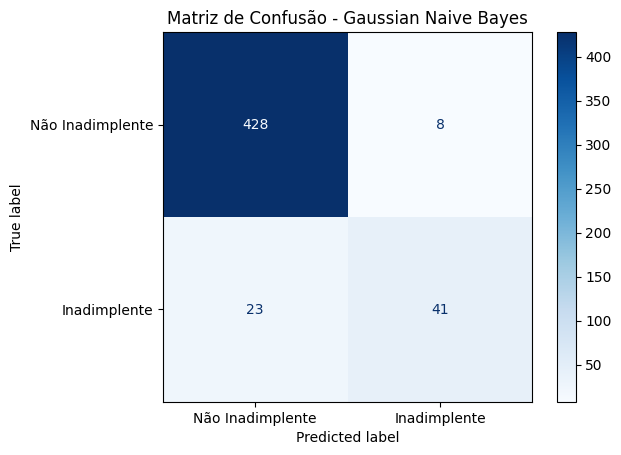

In [76]:
# Gera a matriz de confusão
cm = confusion_matrix(y_df_teste, previsores)

# Exibe a matriz graficamente
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não Inadimplente', 'Inadimplente'])
disp.plot(cmap='Blues')

plt.title('Matriz de Confusão - Gaussian Naive Bayes')
plt.show()